29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


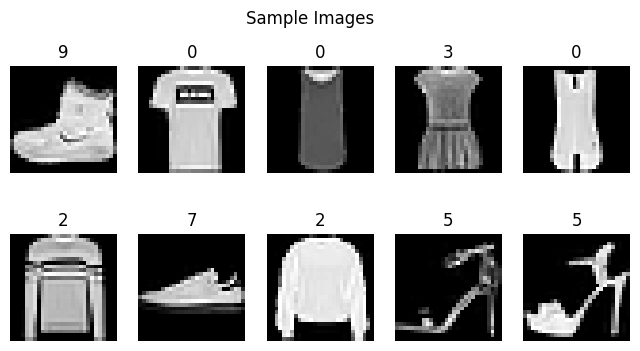

PCA Explained Variance Ratio: [0.29039228 0.1775531 ]
PCA Time: 4.2446277141571045


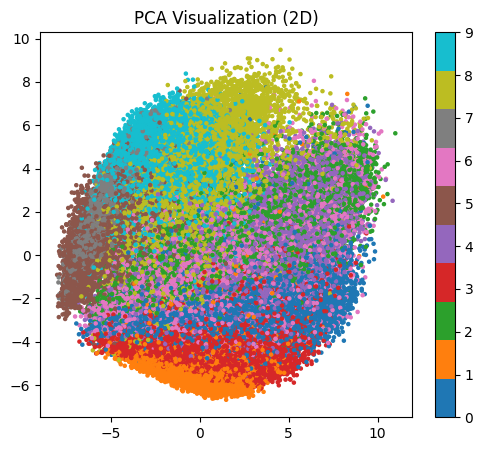

t-SNE Time: 57.023441314697266


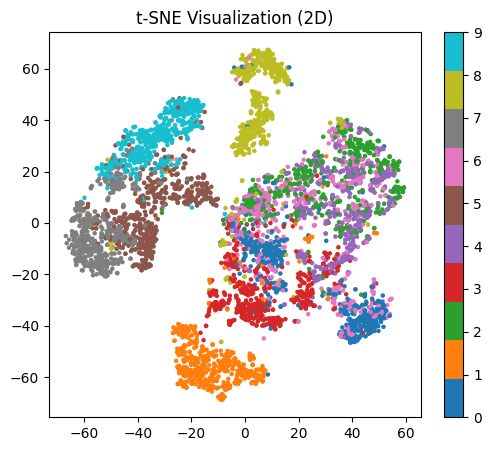


--- Comparison ---
PCA Time: 4.2446277141571045
t-SNE Time: 57.023441314697266
t-SNE is slower but gives better visualization.


In [1]:


import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.datasets import fashion_mnist
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# -----------------------------
# Part A: Load & Prepare Data
# -----------------------------
(x_train, y_train), (_, _) = fashion_mnist.load_data()

# Normalize
x_train = x_train / 255.0

# Flatten images
x_flat = x_train.reshape(x_train.shape[0], -1)

# Show sample images
plt.figure(figsize=(8,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.suptitle("Sample Images")
plt.show()

# -----------------------------
# Part B: PCA
# -----------------------------
start_pca = time.time()

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_flat)

pca_time = time.time() - start_pca

print("PCA Explained Variance Ratio:", pca.explained_variance_ratio_)
print("PCA Time:", pca_time)

# PCA Plot
plt.figure(figsize=(6,5))
plt.scatter(x_pca[:,0], x_pca[:,1], c=y_train, cmap='tab10', s=5)
plt.colorbar()
plt.title("PCA Visualization (2D)")
plt.show()

# -----------------------------
# Part C: t-SNE
# -----------------------------
# Reduce dataset size (for speed)
sample = 5000
x_sample = x_flat[:sample]
y_sample = y_train[:sample]

start_tsne = time.time()

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
x_tsne = tsne.fit_transform(x_sample)

tsne_time = time.time() - start_tsne

print("t-SNE Time:", tsne_time)

# t-SNE Plot
plt.figure(figsize=(6,5))
plt.scatter(x_tsne[:,0], x_tsne[:,1], c=y_sample, cmap='tab10', s=5)
plt.colorbar()
plt.title("t-SNE Visualization (2D)")
plt.show()

# -----------------------------
# Part D: Comparison
# -----------------------------
print("\n--- Comparison ---")
print("PCA Time:", pca_time)
print("t-SNE Time:", tsne_time)

if tsne_time > pca_time:
    print("t-SNE is slower but gives better visualization.")
else:
    print("PCA is faster but less effective for clustering.")